In [15]:

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Trouve la racine du projet (le dossier ELOE-FX)
ROOT = Path(__file__).resolve().parents[1] if '__file__' in globals() else Path.cwd().parent
sys.path.append(str(ROOT))

print("Projet root ajouté :", ROOT)

# Maintenant tu peux importer
from config import settings as S
from strategies.indicators import compute_indicators
from strategies.Ibkr_fx_intraday import plan_order
from strategies.utils import pip_size




Projet root ajouté : c:\Users\Elève\Downloads\ING1_GM\models_finquant\ELOE-FX


In [7]:
csv_path = ROOT / "data" / "historical" / "EURUSD_1min.csv"
df = pd.read_csv(csv_path, parse_dates=["datetime"])
df = df.rename(columns={"datetime":"date"})
df = df.set_index("date").sort_index()

# Harmoniser le fuseau horaire vers Europe/Paris de façon robuste
idx = df.index
if getattr(idx, "tz", None) is None:          # index naive -> on localise en UTC puis on convertit
    df.index = idx.tz_localize("UTC").tz_convert(S.TZ)
else:                                         # index déjà tz-aware -> on convertit directement
    df.index = idx.tz_convert(S.TZ)


# Ne garder que les colonnes utiles
df = df[["open","high","low","close"]].astype(float)
df.head()


,open,high,low,close
date,,,,
2025-08-18 23:15:00+02:00,1.166175,1.166185,1.16617,1.16617
2025-08-18 23:16:00+02:00,1.166170,1.166220,1.16617,1.16622
2025-08-18 23:17:00+02:00,1.166220,1.166220,1.16620,1.16620
2025-08-18 23:18:00+02:00,1.166200,1.166200,1.16620,1.16620
2025-08-18 23:19:00+02:00,1.166200,1.166200,1.16620,1.16620


In [8]:
df_i = compute_indicators(
    df.copy(),
    atr_len=S.ATR_LEN,
    rsi_len=S.RSI_LEN,
    range_lookback=S.BREAKOUT_LOOKBACK
)
df_i.tail()


,open,high,low,close,atr,rsi,range_high,range_low
date,,,,,,,,
2025-08-20 01:01:00+02:00,1.164845,1.164845,1.164670,1.164710,0.000049,40.735520,1.16488,1.164605
2025-08-20 01:02:00+02:00,1.164710,1.164715,1.164690,1.164700,0.000050,39.713850,1.16488,1.164605
2025-08-20 01:03:00+02:00,1.164700,1.164705,1.164520,1.164525,0.000056,26.967203,1.16488,1.164520
2025-08-20 01:04:00+02:00,1.164525,1.164600,1.164510,1.164510,0.000061,26.191228,1.16488,1.164510
2025-08-20 01:05:00+02:00,1.164510,1.164525,1.164495,1.164520,0.000057,27.685166,1.16488,1.164495


In [9]:
def signal_breakout_rsi_row(prev_row, row, rsi_min):
    # BUY si cassure du range_high précédent + RSI >= seuil
    if (row["close"] > prev_row["range_high"]) and (row["rsi"] >= rsi_min):
        return "BUY"
    # SELL si cassure du range_low précédent + RSI <= (100 - seuil)
    if (row["close"] < prev_row["range_low"]) and (row["rsi"] <= (100 - rsi_min)):
        return "SELL"
    return None

# Crée une série de signaux (None/BUY/SELL)
signals = []
for i in range(len(df_i)):
    if i < 1:
        signals.append(None)
        continue
    prev = df_i.iloc[i-1]
    row  = df_i.iloc[i]
    # sécurité: il faut que les ranges soient définis
    if np.isnan(prev.get("range_high")) or np.isnan(prev.get("range_low")):
        signals.append(None); continue
    sig = signal_breakout_rsi_row(prev, row, S.RSI_MIN)
    signals.append(sig)

df_i["signal"] = signals
df_i["signal"].value_counts(dropna=False)


signal
None    1393
SELL      74
BUY       69
Name: count, dtype: int64

In [14]:
PAIR = "EURUSD"
PS = pip_size(PAIR)

def backtest_breakout(df_ind, rr=S.RR, atr_k=S.ATR_K, min_stop_pips=S.MIN_STOP_PIPS, lookahead=120):
    """
    À chaque signal, on simule une entrée à la close de la bougie du signal,
    puis on regarde dans les 'lookahead' prochaines bougies si le TP ou le SL est touché en premier.
    On renvoie la liste des trades et un DataFrame equity.
    """
    trades = []
    equity = [0.0]  # PnL cumulé en unités de risque
    pnl_cum = 0.0

    for i in range(len(df_ind)):
        sig = df_ind["signal"].iloc[i]
        if sig is None:
            equity.append(pnl_cum)
            continue

        # Construire un plan (SL/TP) à partir de ton sizing fonction de l'ATR
        price = float(df_ind["close"].iloc[i])
        atr   = float(df_ind["atr"].iloc[i]) if "atr" in df_ind.columns else np.nan
        plan  = plan_order(PAIR, price, atr, sig)

        # Scanner en avant
        hit = None
        end_idx = min(i+lookahead, len(df_ind)-1)
        highs = df_ind["high"].iloc[i+1:end_idx+1].values
        lows  = df_ind["low"].iloc[i+1:end_idx+1].values

        if sig == "BUY":
            tp_first = np.argmax(highs >= plan.take) if np.any(highs >= plan.take) else 0
            sl_first = np.argmax(lows  <= plan.stop) if np.any(lows  <= plan.stop) else 0
        else:
            tp_first = np.argmax(lows  <= plan.take) if np.any(lows  <= plan.take) else 0
            sl_first = np.argmax(highs >= plan.stop) if np.any(highs >= plan.stop) else 0

        # Décision TP vs SL (0 => pas touché)
        if tp_first and sl_first:
            hit = "TP" if tp_first <= sl_first else "SL"
        elif tp_first:
            hit = "TP"
        elif sl_first:
            hit = "SL"
        else:
            hit = "NONE"  # ni TP ni SL dans l'horizon

        # PnL en unités de risque (R): TP = +RR, SL = -1, NONE = 0
        pnl_r = {"TP": rr, "SL": -1.0, "NONE": 0.0}[hit]
        pnl_cum += pnl_r
        equity.append(pnl_cum)

        trades.append({
            "i": i,
            "time": df_ind.index[i],
            "side": sig,
            "entry": plan.entry,
            "stop": plan.stop,
            "take": plan.take,
            "result": hit,
            "pnl_r": pnl_r
        })

    # aligne equity (première valeur dummy)
    equity = pd.Series(equity[1:], index=df_ind.index)
    return pd.DataFrame(trades), equity

trades, equity = backtest_breakout(df_i)
len(trades), trades[:5], equity.tail()


(143,
     i                      time side     entry     stop     take result  pnl_r
 0  46 2025-08-19 00:01:00+02:00  BUY  1.166310  1.16481  1.16856   NONE    0.0
 1  49 2025-08-19 00:04:00+02:00  BUY  1.166545  1.16504  1.16880   NONE    0.0
 2  50 2025-08-19 00:05:00+02:00  BUY  1.166965  1.16546  1.16922   NONE    0.0
 3  52 2025-08-19 00:07:00+02:00  BUY  1.167250  1.16575  1.16950   NONE    0.0
 4  53 2025-08-19 00:08:00+02:00  BUY  1.167380  1.16588  1.16963   NONE    0.0,
 date
 2025-08-20 01:01:00+02:00   -15.5
 2025-08-20 01:02:00+02:00   -15.5
 2025-08-20 01:03:00+02:00   -15.5
 2025-08-20 01:04:00+02:00   -15.5
 2025-08-20 01:05:00+02:00   -15.5
 dtype: float64)

Trades: 143 | Wins: 5 | Losses: 23 | NoHit: 115
Hit rate: 17.86% | EV (R): -0.554
PnL total (R): -15.50
Max Drawdown (R): -15.50
Sharpe (approx): -21.23


C:\Users\Elève\AppData\Local\Temp\ipykernel_1856\67979580.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  eq = equity.fillna(method="ffill").fillna(0.0) if equity is not None else None


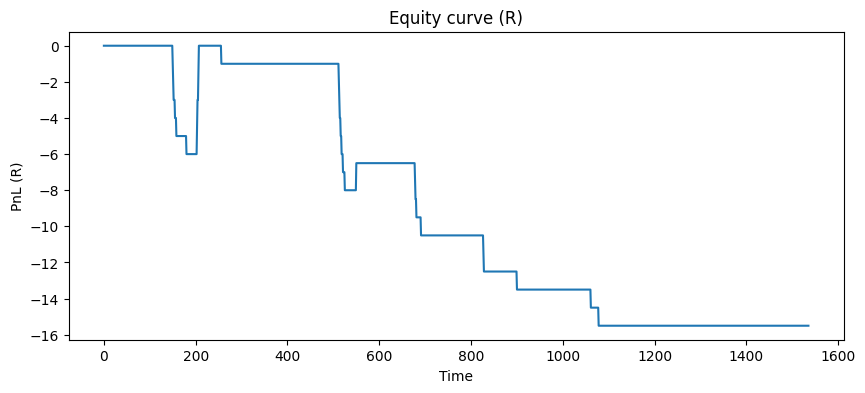

In [17]:

# Sécurité si aucun trade
if trades is None or len(trades) == 0:
    print("Aucun trade à analyser.")
else:
    # Comptages directs sur les colonnes du DataFrame
    n = len(trades)
    wins = (trades["result"] == "TP").sum()
    loss = (trades["result"] == "SL").sum()
    none = (trades["result"] == "NONE").sum()
    hit_rate = wins / max(1, (wins + loss))

    # EV en unités de risque (R), sans frais
    ev = hit_rate * S.RR - (1 - hit_rate)

    # PnL cumulé en R (déjà fourni par equity), avec garde-fou si equity vide
    pnl_total = float(equity.iloc[-1]) if equity is not None and len(equity) > 0 else 0.0

    print(f"Trades: {n} | Wins: {wins} | Losses: {loss} | NoHit: {none}")
    print(f"Hit rate: {hit_rate:.2%} | EV (R): {ev:.3f}")
    print(f"PnL total (R): {pnl_total:.2f}")

    # Drawdown
    eq = equity.fillna(method="ffill").fillna(0.0) if equity is not None else None
    if eq is not None and len(eq) > 0:
        roll_max = eq.cummax()
        dd = eq - roll_max
        max_dd = dd.min()
        print(f"Max Drawdown (R): {max_dd:.2f}")

        # Sharpe (approx en R par pas de temps)
        rets = np.diff(eq.values, prepend=0.0)
        sharpe = (np.mean(rets) / np.std(rets) * np.sqrt(252*6.5*60)) if np.std(rets) > 1e-9 else 0.0
        print(f"Sharpe (approx): {sharpe:.2f}")

        # Courbe d'equity
        plt.figure(figsize=(10,4))
        plt.plot(eq.values)
        plt.title("Equity curve (R)")
        plt.xlabel("Time")
        plt.ylabel("PnL (R)")
        plt.show()
    else:
        print("Pas d'equity à tracer.")

In [19]:


def run_once(rr, atr_k, rsi_min, min_stop_pips, lookahead=120):
    # on travaille sur une copie des indicateurs
    df_t = df_i.copy()

    # sauvegarde puis override temporaire des paramètres globaux
    old = (S.RR, S.ATR_K, S.RSI_MIN, S.MIN_STOP_PIPS)
    S.RR, S.ATR_K, S.RSI_MIN, S.MIN_STOP_PIPS = rr, atr_k, rsi_min, min_stop_pips

    # backtest
    trades_t, equity_t = backtest_breakout(
        df_t, rr=rr, atr_k=atr_k, min_stop_pips=min_stop_pips, lookahead=lookahead
    )

    # métriques robustes (DataFrame)
    if isinstance(trades_t, pd.DataFrame) and len(trades_t) > 0:
        wins = (trades_t["result"] == "TP").sum()
        loss = (trades_t["result"] == "SL").sum()
        taken = wins + loss
        hit  = (wins / taken) if taken > 0 else 0.0
        ev   = hit*rr - (1 - hit)  # EV en R, sans frais
        pnl  = float(equity_t.iloc[-1]) if len(equity_t) else 0.0
        ntr  = int(len(trades_t))
    else:
        ev = pnl = hit = 0.0
        ntr = 0

    # restore paramètres
    S.RR, S.ATR_K, S.RSI_MIN, S.MIN_STOP_PIPS = old
    return {"pnl": pnl, "ev": ev, "hit": hit, "trades": ntr}

grid = {
    "RR": [1.2, 1.5, 2.0],
    "ATR_K": [0.8, 1.0, 1.2],
    "RSI_MIN": [55, 58, 60],
    "MIN_STOP_PIPS": [10, 15, 20]
}

rows = []
for rr in grid["RR"]:
    for ak in grid["ATR_K"]:
        for rsi in grid["RSI_MIN"]:
            for msp in grid["MIN_STOP_PIPS"]:
                m = run_once(rr, ak, rsi, msp, lookahead=120)
                rows.append({"RR": rr, "ATR_K": ak, "RSI_MIN": rsi, "MIN_STOP_PIPS": msp, **m})

res_df = pd.DataFrame(rows).sort_values(["ev","pnl"], ascending=[False, False]).reset_index(drop=True)
display(res_df.head(10))

# (optionnel) meilleur jeu
if not res_df.empty:
    best = res_df.iloc[0].to_dict()
    print("Best params:", best)


,RR,ATR_K,RSI_MIN,MIN_STOP_PIPS,pnl,ev,hit,trades
0,1.2,0.8,55,10,0.8,0.010811,0.459459,143
1,1.2,0.8,58,10,0.8,0.010811,0.459459,143
2,1.2,0.8,60,10,0.8,0.010811,0.459459,143
3,1.2,1.0,55,10,0.8,0.010811,0.459459,143
4,1.2,1.0,58,10,0.8,0.010811,0.459459,143
5,1.2,1.0,60,10,0.8,0.010811,0.459459,143
6,1.2,1.2,55,10,0.8,0.010811,0.459459,143
7,1.2,1.2,58,10,0.8,0.010811,0.459459,143
8,1.2,1.2,60,10,0.8,0.010811,0.459459,143
9,1.5,0.8,55,10,-11.5,-0.194915,0.322034,143


Best params: {'RR': 1.2, 'ATR_K': 0.8, 'RSI_MIN': 55.0, 'MIN_STOP_PIPS': 10.0, 'pnl': 0.8000000000000032, 'ev': 0.010810810810810811, 'hit': 0.4594594594594595, 'trades': 143.0}


In [20]:
best = res_df.iloc[0].to_dict()
best


{'RR': 1.2,
 'ATR_K': 0.8,
 'RSI_MIN': 55.0,
 'MIN_STOP_PIPS': 10.0,
 'pnl': 0.8000000000000032,
 'ev': 0.010810810810810811,
 'hit': 0.4594594594594595,
 'trades': 143.0}

In [21]:
# 1. Optimisation walk-forward(réduit l'overfitting)
# Cellule A — Découpage temporel + wrapper évaluation

import pandas as pd
import numpy as np

def time_splits(df, n_splits=4):
    """Découpage chronologique simple: on avance la fenêtre (expanding train, fixed test)."""
    n = len(df)
    fold = n // (n_splits + 1)
    for i in range(n_splits):
        train = df.iloc[: (i+1)*fold]
        test  = df.iloc[(i+1)*fold : (i+2)*fold]
        if len(test) == 0: 
            break
        yield train, test

def eval_params_walkforward(df_i, rr, atr_k, rsi_min, min_stop_pips, lookahead=120):
    from copy import deepcopy
    old = (S.RR, S.ATR_K, S.RSI_MIN, S.MIN_STOP_PIPS)
    S.RR, S.ATR_K, S.RSI_MIN, S.MIN_STOP_PIPS = rr, atr_k, rsi_min, min_stop_pips

    evs, pnls, hits, counts = [], [], [], []
    for tr, te in time_splits(df_i.dropna(), n_splits=4):
        # on backteste uniquement sur la période **test**
        trades_te, equity_te = backtest_breakout(te.copy(), rr=rr, atr_k=atr_k, min_stop_pips=min_stop_pips, lookahead=lookahead)
        if len(trades_te)==0: 
            continue
        wins = (trades_te["result"]=="TP").sum()
        loss = (trades_te["result"]=="SL").sum()
        taken = wins+loss
        hit = wins/max(1,taken)
        ev  = hit*rr - (1-hit)
        pnl = float(equity_te.iloc[-1]) if len(equity_te)>0 else 0.0
        evs.append(ev); pnls.append(pnl); hits.append(hit); counts.append(len(trades_te))

    S.RR, S.ATR_K, S.RSI_MIN, S.MIN_STOP_PIPS = old
    if not evs:
        return {"ev":0,"pnl":0,"hit":0,"trades":0}
    return {"ev":np.mean(evs), "pnl":np.mean(pnls), "hit":np.mean(hits), "trades":int(np.sum(counts))}


In [22]:
# Cellule B — Grid walk-forward

grid = {
    "RR": [1.2, 1.5, 2.0],
    "ATR_K": [0.8, 1.0, 1.2],
    "RSI_MIN": [55, 58, 60],
    "MIN_STOP_PIPS": [10, 15, 20]
}

rows = []
for rr in grid["RR"]:
    for ak in grid["ATR_K"]:
        for rsi in grid["RSI_MIN"]:
            for msp in grid["MIN_STOP_PIPS"]:
                m = eval_params_walkforward(df_i, rr, ak, rsi, msp, lookahead=120)
                rows.append({"RR":rr,"ATR_K":ak,"RSI_MIN":rsi,"MIN_STOP_PIPS":msp, **m})

wf_df = pd.DataFrame(rows).sort_values(["ev","pnl"], ascending=[False,False]).reset_index(drop=True)
display(wf_df.head(10))
best_wf = wf_df.iloc[0].to_dict() if not wf_df.empty else None
best_wf


,RR,ATR_K,RSI_MIN,MIN_STOP_PIPS,ev,pnl,hit,trades
0,1.2,0.8,55,10,0.283333,3.0,0.583333,112
1,1.2,0.8,58,10,0.283333,3.0,0.583333,112
2,1.2,0.8,60,10,0.283333,3.0,0.583333,112
3,1.2,1.0,55,10,0.283333,3.0,0.583333,112
4,1.2,1.0,58,10,0.283333,3.0,0.583333,112
5,1.2,1.0,60,10,0.283333,3.0,0.583333,112
6,1.2,1.2,55,10,0.283333,3.0,0.583333,112
7,1.2,1.2,58,10,0.283333,3.0,0.583333,112
8,1.2,1.2,60,10,0.283333,3.0,0.583333,112
9,1.2,0.8,55,15,0.244048,1.1,0.565476,112


{'RR': 1.2,
 'ATR_K': 0.8,
 'RSI_MIN': 55.0,
 'MIN_STOP_PIPS': 10.0,
 'ev': 0.2833333333333333,
 'pnl': 3.0000000000000004,
 'hit': 0.5833333333333334,
 'trades': 112.0}

In [23]:
# 2. Modèle probabiliste “TP avant SL” (logit basique)
# Cellule C — Labelling + features + entraînement

from sklearn.linear_model import LogisticRegression
import numpy as np

def label_tp_before_sl(df, rr, atr_k, min_stop_pips, pip_size, lookahead=120):
    df = df.copy()
    y = np.zeros(len(df), dtype=np.float32)
    highs, lows, closes = df["high"].to_numpy(), df["low"].to_numpy(), df["close"].to_numpy()
    for i in range(len(df)-lookahead):
        atr = df["atr"].iloc[i]
        stop_pips = max((atr/pip_size)*atr_k, min_stop_pips) if np.isfinite(atr) else min_stop_pips
        stop_dist = stop_pips * pip_size
        entry = closes[i]
        tp_buy, sl_buy = entry + rr*stop_dist, entry - stop_dist
        # on suppose trade BUY ici; on peut entraîner SELL séparé si tu veux
        h_slice = highs[i+1:i+1+lookahead]
        l_slice = lows[i+1:i+1+lookahead]
        tp_idx = np.argmax(h_slice >= tp_buy) if np.any(h_slice >= tp_buy) else 0
        sl_idx = np.argmax(l_slice <= sl_buy) if np.any(l_slice <= sl_buy) else 0
        if tp_idx and sl_idx: y[i] = 1.0 if tp_idx <= sl_idx else 0.0
        elif tp_idx:          y[i] = 1.0
        elif sl_idx:          y[i] = 0.0
        else:                 y[i] = 0.0
    df["y_buy"] = y
    return df

def build_features(df):
    out = df.copy()
    out["range_high_dist"] = (out["close"] - out["range_high"]) / out["atr"]
    out["range_low_dist"]  = (out["range_low"] - out["close"]) / out["atr"]
    out["atr_med"] = out["atr"].rolling(60, min_periods=30).median()
    out["vol_regime"] = out["atr"] / out["atr_med"]
    h = out.index.tz_convert(S.TZ).hour.astype(float)
    out["hour_sin"] = np.sin(2*np.pi*h/24)
    out["hour_cos"] = np.cos(2*np.pi*h/24)
    # drop NaN features
    feats = ["rsi","atr","range_high_dist","range_low_dist","vol_regime","hour_sin","hour_cos"]
    out = out.dropna(subset=feats)
    return out, feats

# 1) utilise les meilleurs params walk-forward (sinon S.* à défaut)
RR_   = best_wf["RR"] if best_wf else S.RR
AK_   = best_wf["ATR_K"] if best_wf else S.ATR_K
RMIN_ = best_wf["RSI_MIN"] if best_wf else S.RSI_MIN
MSP_  = best_wf["MIN_STOP_PIPS"] if best_wf else S.MIN_STOP_PIPS

# 2) On labellise BUY seulement (tu peux faire SELL à part)
ps = pip_size("EURUSD")
df_lab = label_tp_before_sl(df_i, rr=RR_, atr_k=AK_, min_stop_pips=MSP_, pip_size=ps, lookahead=120)

# 3) On restreint aux lignes où ta règle donne un signal BUY (breakout + RSI)
cond_buy = (df_i["close"] > df_i["range_high"].shift(1)) & (df_i["rsi"] >= RMIN_)
df_train = df_lab[cond_buy].dropna(subset=["y_buy"]).copy()

# 4) Features + fit
df_feat, FEATURES = build_features(df_train)
X = df_feat[FEATURES].values
y = df_train.loc[df_feat.index, "y_buy"].values

clf = LogisticRegression(max_iter=500, class_weight="balanced")
clf.fit(X, y)

print("Train hit_rate:", y.mean(), " | classes:", np.unique(y, return_counts=True))


Train hit_rate: 0.3  | classes: (array([0., 1.], dtype=float32), array([28, 12]))


In [25]:
# Cellule D — Seuil EV et sauvegarde modèle

import joblib, os

# Seuil EV: p > 1/(1+RR) + marge (ex: 0.05)
thr = 1.0/(1.0+RR_) + 0.05
print("Seuil proba EV>0:", round(thr,3))

os.makedirs("../models", exist_ok=True)
joblib.dump({"model": clf, "features": FEATURES, "rr": RR_, "threshold": thr}, "../models/model_eurusd_buy.pkl")
print("✅ Modèle sauvegardé -> models/model_eurusd_buy.pkl")


Seuil proba EV>0: 0.505
✅ Modèle sauvegardé -> models/model_eurusd_buy.pkl
